#### Configurações iniciais do projeto

In [198]:
import urllib.request
import urllib.error
import re
import time
import datetime
import os
import pandas as pd
from bs4 import BeautifulSoup
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt


os.makedirs("database", exist_ok=True)

ENGINE = create_engine("sqlite:///database/linguagens.db", echo=False)
INICIAIS_PERMITIDAS = set("CJP")
MAX_LINGUAGENS = 160
URL_INDICE = "https://en.wikipedia.org/wiki/List_of_programming_languages"
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (compatible; ProjetoInfnet/1.0; " "+https://www.infnet.edu.br)"
    )
}

# Rótulos identificados durante a análise exploratória das infoboxes 
# das linguagens da Wikipédia.

CAMPOS = {
    "ano_criacao": {
        "appeared",
        "created",
        "designed",
        "first appeared",
        "initial release",
        "release",
        "founded",
        "formation",
        "year",
    },
    "criador": {
        "author",
        "creator",
        "designer",
        "designed by",
        "original author",
        "original authors",
        "writer",
    },
    "paradigma": {"paradigm", "paradigms"},
    "tipagem": {"typing", "type system", "typing discipline"},
}

#### Criação de Tabelas

In [199]:
def criar_tabelas(engine):
    with engine.connect() as conn:
        conn.execute(text("""
                          CREATE TABLE IF NOT EXISTS linguagens 
                          (
                              id INTEGER PRIMARY KEY,
                              nome TEXT,
                              ano_criacao INTEGER,
                              criador TEXT,
                              paradigma TEXT,
                              tipagem TEXT,
                              url_wikipedia TEXT
                          )
                                                    """))
        conn.execute(text("""
                          CREATE TABLE IF NOT EXISTS paginas_visitadas 
                          (
                              id INTEGER PRIMARY KEY,
                              url TEXT,
                              http_status INTEGER,
                              timestamp TEXT,
                              linguagem_id INTEGER,
                              FOREIGN KEY (linguagem_id) REFERENCES linguagens(id)
                          )
                          """))
        conn.execute(text("""
                          CREATE TABLE IF NOT EXISTS erros_scraping 
                          (
                            id INTEGER PRIMARY KEY,
                            url TEXT,
                            tipo_erro TEXT,
                            mensagem TEXT,
                            timestamp TEXT      
                          )
                          
                          """))
        conn.commit()
        
        
criar_tabelas(ENGINE)

#### Download da página índice

In [200]:
def download_pagina(url: str):
    req = urllib.request.Request(url, headers=HEADERS)
    with urllib.request.urlopen(req, timeout=10) as resp:
        status = resp.status
        html = resp.read()
    return status, html
        
download_pagina(URL_INDICE)  

(200,
 b'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-not-available skin-thumbsize-clientpref-standard" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>List of programming languages - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-featur

#### Extração dos links de cada linguagem

In [201]:
def get_links_linguagens(url:str):
    
    status, html = download_pagina(url)
    
    soup = BeautifulSoup(html, 'html.parser') #converte string html em objeto Beautifulsoup
    
    links_linguagens = [] 
    for link in soup.select('div.div-col li a'):
       href = str(link.get('href', ''))
       nome = link.get_text(strip=True)
       if not nome or not href.startswith('/wiki/'):
            continue
       if nome[0].upper() not in INICIAIS_PERMITIDAS:
            continue
       url_linguagem = 'https://en.wikipedia.org' + str(href) 
       links_linguagens.append((nome, url_linguagem))
       
    return links_linguagens
        
get_links_linguagens(URL_INDICE)

[('C', 'https://en.wikipedia.org/wiki/C_(programming_language)'),
 ('C--', 'https://en.wikipedia.org/wiki/C--'),
 ('C++', 'https://en.wikipedia.org/wiki/C%2B%2B'),
 ('C*', 'https://en.wikipedia.org/wiki/C*'),
 ('C#', 'https://en.wikipedia.org/wiki/C_Sharp_(programming_language)'),
 ('C/AL', 'https://en.wikipedia.org/wiki/C/AL'),
 ('Caché ObjectScript',
  'https://en.wikipedia.org/wiki/Cach%C3%A9_ObjectScript'),
 ('C Shell (csh)', 'https://en.wikipedia.org/wiki/C_Shell'),
 ('Calcpad', 'https://en.wikipedia.org/wiki/Calcpad'),
 ('Caml', 'https://en.wikipedia.org/wiki/Caml'),
 ('Carbon', 'https://en.wikipedia.org/wiki/Carbon_(programming_language)'),
 ('Catrobat', 'https://en.wikipedia.org/wiki/Catrobat'),
 ('Cayenne (Lennart Augustsson)',
  'https://en.wikipedia.org/wiki/Cayenne_(programming_language)'),
 ('Cecil', 'https://en.wikipedia.org/wiki/Cecil_(programming_language)'),
 ('CESIL (Computer Education in Schools Instruction Language)',
  'https://en.wikipedia.org/wiki/CESIL'),
 ('CEE

#### Análise Exploratória dos rótulos de dados necessários


In [202]:
def analisar_rotulos(links: list[tuple[str, str]]):

    rotulos_encontrados = set()

    for nome, url in links:

        status, html = download_pagina(url)
        soup = BeautifulSoup(html, "html.parser")

        for linha in soup.select("tr"):

            th = linha.find("th", class_="infobox-label")

            if th is None:
                continue

            th = th.get_text(separator=" ", strip=True).lower()
            th = th.replace("\xa0", " ")

            rotulos_encontrados.add(th)

    for rotulo in sorted(rotulos_encontrados):
        print(rotulo)
        
analisar_rotulos(get_links_linguagens(URL_INDICE))

2021
2023
area served
artist
available in
born
company type
composers
default user interface
defunct
designed by
designer
developed by
developer
developers
director
education
extended to
family
fate
fields
file formats
filename extension
filename extensions
final release
first appeared
formation
founded
founder
genre
headquarters
implementation language
industry
initial release
institutions
internet media type
kernel type
key people
known for
latest release
license
magic number
memory management
modes
occupations
operating system
organization(s)
original author
original authors
os
os family
paradigm
paradigms
platform
platforms
preview release
producer
publisher
release
repository
scope
series
services
stable release
subsidiaries
successor
supported platforms
traded as
type
type of format
typing discipline
uniform type identifier (uti)
website
working state
writer
written in


#### Captura, gestão de erros e salvamento dos dados

In [203]:
def get_dados(links: list[tuple[str, str]]):

    for nome, url in links:
        try:
            status, html = download_pagina(url)
            if status != 200:
                continue
            print(f"\nStatus HTTP: {status}. Iniciando scraping de informações sobre a linguagem {nome}...")

            soup = BeautifulSoup(html, "html.parser")
            ano_criacao = None
            criador = None
            paradigma = None
            tipagem = None

            # nome da linguagem
            nome = soup.find("h1", id="firstHeading")
            if nome:
                nome = nome.get_text(strip=True)
            else:
                "desconhecido"

            # acessando table headers e obtendo identificador do CAMPO
            for linha in soup.select("tr"):
                th = linha.find("th", class_="infobox-label")

                if th is None:
                    continue

                th = th.get_text(separator=" ", strip=True).lower()
                th = th.replace("\xa0", " ")

                # ano_criacao
                if th in CAMPOS["ano_criacao"]:
                    td = linha.find("td", class_="infobox-data")

                    if td is not None:
                        ano = td.get_text(" ", strip=True)
                        ano = re.search(r"\b(\d{4})\b", ano)

                        if ano is not None:
                            ano_criacao = int(ano.group(1))

                # criador
                if th in CAMPOS["criador"]:
                    td = linha.find("td", class_="infobox-data")

                    if td is not None:
                        criador = td.get_text(" ", strip=True)

                # paradigma
                if th in CAMPOS["paradigma"]:
                    td = linha.find("td", class_="infobox-data")

                    if td is not None:
                        paradigma = td.get_text(" ", strip=True)

                # tipagem
                if th in CAMPOS["tipagem"]:
                    td = linha.find("td", class_="infobox-data")

                    if td is not None:
                        tipagem = td.get_text(" ", strip=True)

            print(nome, ano_criacao, criador, paradigma, tipagem)

            """ Codigo para salvar a linguagem e os dados. Nao foi necessário criar ou receber id pois esse atributo é autoincrementavel na tabela do SQLLite. É boa prática deixar o banco gerar os ids."""

            df_linguagem = pd.DataFrame(
                [
                    {
                        "nome": nome,
                        "ano_criacao": ano_criacao,
                        "criador": criador,
                        "paradigma": paradigma,
                        "tipagem": tipagem,
                        "url_wikipedia": url,
                    }
                ]
            )
            df_linguagem["nome"] = df_linguagem["nome"].str.strip()
            df_linguagem.to_sql("linguagens", ENGINE, if_exists="append", index=False)

            df_id = pd.read_sql(
                """
                    SELECT id
                    FROM linguagens
                    WHERE url_wikipedia = ?
                    """,
                ENGINE,
                params=(url,),
            )

            linguagem_id = int(df_id.iloc[0]["id"])

            # Codigo para salvar a visita

            df_paginas_visitadas = pd.DataFrame(
                [
                    {
                        "url": url,
                        "http_status": status,
                        "timestamp": datetime.datetime.now().strftime(
                            "%Y-%m-%d %H:%M:%S"
                        ),
                        "linguagem_id": linguagem_id,
                    }
                ]
            )

            df_paginas_visitadas.to_sql(
                "paginas_visitadas", ENGINE, if_exists="append", index=False
            )
            
        #erros de resposta do servidor
        except urllib.error.HTTPError as e: 
            df_erro = pd.DataFrame(
                [
                    {
                        "url": url,
                        "tipo_erro": type(e).__name__,
                        "mensagem": str(e),
                        "timestamp": datetime.datetime.now().strftime(
                            "%Y-%m-%d %H:%M:%S"
                        ),
                    }
                ]
            )
            df_erro.to_sql("erros_scraping", ENGINE, if_exists="append", index=False)
            pass
        
        #erros de conexão ou acesso à URL
        except urllib.error.URLError as e:            
            df_erro = pd.DataFrame(
                [
                    {
                        "url": url,
                        "tipo_erro": type(e).__name__,
                        "mensagem": str(e),
                        "timestamp": datetime.datetime.now().strftime(
                            "%Y-%m-%d %H:%M:%S"
                        ),
                    }
                ]
            )
            df_erro.to_sql("erros_scraping", ENGINE, if_exists="append", index=False)
            pass
    
        # Não foi implementado tratamento para AttributeError, 
        # pois os campos são inicializados com None e permanecem 
        # assim quando a informação não está disponível na infobox.       
        
        # Inclui o Exception a seguir para erros inesperados 
        # não contemplados pelos tratamentos acima.
        
        except Exception as e:
            df_erro = pd.DataFrame(
                [
                    {
                        "url": url,
                        "tipo_erro": type(e).__name__,
                        "mensagem": str(e),
                        "timestamp": datetime.datetime.now().strftime(
                            "%Y-%m-%d %H:%M:%S"
                        ),
                    }
                ]
            )
            df_erro.to_sql("erros_scraping", ENGINE, if_exists="append", index=False)
            pass

        finally:
            time.sleep(0.5)

        

links = get_links_linguagens(URL_INDICE)

get_dados(links[:MAX_LINGUAGENS])



Status HTTP: 200. Iniciando scraping de informações sobre a linguagem C...
C (programming language) 1972 Dennis Ritchie Multi-paradigm : imperative ( procedural ), structured Static , weak , manifest , nominal

Status HTTP: 200. Iniciando scraping de informações sobre a linguagem C--...
C-- 1998 Simon Peyton Jones and Norman Ramsey imperative static , weak

Status HTTP: 200. Iniciando scraping de informações sobre a linguagem C++...
C++ 1985 Bjarne Stroustrup Multi-paradigm : procedural , imperative , functional , object-oriented , generic , modular , reflective [ 1 ] , Design by contract Static , strong , nominative , partially inferred

Status HTTP: 200. Iniciando scraping de informações sobre a linguagem C*...
C* 1987 Thinking Machines multi-paradigm : imperative , parallel static , weak , manifest

Status HTTP: 200. Iniciando scraping de informações sobre a linguagem C#...
C Sharp (programming language) 2000 Anders Hejlsberg ( Microsoft ) Multi-paradigm : structured , imperative ,

#### Verificação de integridade de dados

In [204]:
with ENGINE.connect() as conn:
    df_linguagens = pd.read_sql (""" SELECT * from linguagens """, conn)
    df_paginas_visitadas = pd.read_sql (""" SELECT * FROM paginas_visitadas""", conn )
    df_erros = pd.read_sql (""" SELECT * FROM erros_scraping """, conn)
    
print(f'Quantidade de linguagens: {len(df_linguagens)}')
print(f'Quantidade de paginas visitadas: {len(df_paginas_visitadas)}')
print(f'Quantidade de erros: {len(df_erros)}')

Quantidade de linguagens: 154
Quantidade de paginas visitadas: 154
Quantidade de erros: 0


#### Consultas SQL

In [205]:
# Consulta 1 — Linguagens criadas a partir de 1990 scrapeadas com sucesso

with ENGINE.connect() as conn:
    df_pos_1990 = pd.read_sql(
        """ SELECT L.id as ID, 
        L.nome as Linguagem, 
        L.ano_criacao as Ano_Criação, 
        P.http_status as HTTP_STATUS 
        FROM linguagens L 
        INNER JOIN paginas_visitadas P 
        ON L.id = P.linguagem_id 
        WHERE L.ano_criacao >= 1990 
        AND P.http_status = 200
        ORDER BY L.ano_criacao""",
        conn
    )

print(f"Tabela de linguagens criadas após 1990:")
df_pos_1990

Tabela de linguagens criadas após 1990:


,ID,Linguagem,Ano_Criação,HTTP_STATUS
0,69,J (programming language),1990,200
1,75,Janus (concurrent constraint programming langu...,1990,200
2,51,Constraint Handling Rules,1991,200
3,136,POV-Ray,1991,200
4,154,Python (programming language),1991,200
...,...,...,...,...
58,17,Céu (programming language),2014,200
59,58,Crystal (programming language),2014,200
60,131,Pony (programming language),2015,200
61,144,Project Verona,2019,200


In [206]:
# Consulta 2 — Linguagens que geraram erros durante o scraping

with ENGINE.connect() as conn:
    df_erros = pd.read_sql(
        """ SELECT 
        L.id as ID, 
        L.nome as Linguagem,
        E.tipo_erro,
        E.mensagem,
        E.timestamp 
        FROM erros_scraping E 
        LEFT JOIN linguagens L 
        ON L.url_wikipedia = E.url 
        ORDER BY E.timestamp
        """,
        conn
    )
    
    contagem = pd.read_sql(
        """
        SELECT COUNT(tipo_erro)
        AS total_erros
        FROM erros_scraping
        
        """, conn
    )
    

print(f"Total de erros: {contagem.iloc[0]['total_erros']}")
print(f"Tabela com linguagens que geraram erros durante o scraping:")

df_erros



Total de erros: 0
Tabela com linguagens que geraram erros durante o scraping:


,ID,Linguagem,tipo_erro,mensagem,timestamp


In [207]:
# Consulta 3 — Taxa de sucesso do scraping por paradigma

with ENGINE.connect() as conn:
    df_sucesso = pd.read_sql(
        """
        SELECT
            L.paradigma,
            COUNT(DISTINCT L.id) AS total_linguagens,
            SUM(CASE WHEN p.http_status = 200  THEN 1 ELSE 0 END) AS scraping_sucesso,
            SUM(CASE WHEN p.http_status != 200 THEN 1 ELSE 0 END) AS scraping_falha
        FROM linguagens L
        INNER JOIN paginas_visitadas P
            ON P.linguagem_id = L.id
        GROUP BY L.paradigma
        ORDER BY total_linguagens DESC
        """,
        conn,
    )

df_sucesso

# Observação:
# As falhas de scraping são registradas na tabela erros_scraping.
# Como o paradigma só é conhecido após a extração bem-sucedida da
# página, esta consulta, baseada no modelo de dados adotado,
# não consegue associar as falhas aos respectivos paradigmas. 



,paradigma,total_linguagens,scraping_sucesso,scraping_falha
0,None,55,55,0
1,"Procedural , imperative , structured",4,4,0
2,object-oriented,3,3,0
3,functional,3,3,0
4,Object-oriented,3,3,0
...,...,...,...,...
80,"Constraint logic , declarative",1,1,0
81,Concurrent,1,1,0
82,"Array , functional , object-oriented ( class-b...",1,1,0
83,Array,1,1,0


#### Relatório Final

  RELATÓRIO FINAL
Total de páginas visitadas: 154
Total de linguagens salvas: 154
Total de erros: 0


,ID,Linguagem,tipo_erro,mensagem,timestamp


DISTRIBUIÇÃO DE ERROS POR TIPO DE EXCEÇÃO
* Nenhum erro foi registrado durante o scraping
QUANTIDADE DE LINGUAGENS POR PARADIGMA


,Paradigma,Quantidade,Percentual
0,None,55,35.71
1,"Procedural , imperative , structured",4,2.60
2,object-oriented,3,1.95
3,functional,3,1.95
4,Object-oriented,3,1.95
...,...,...,...
80,"Constraint logic , declarative",1,0.65
81,Concurrent,1,0.65
82,"Array , functional , object-oriented ( class-b...",1,0.65
83,Array,1,0.65


Gráfico Top 10 Paradigmas


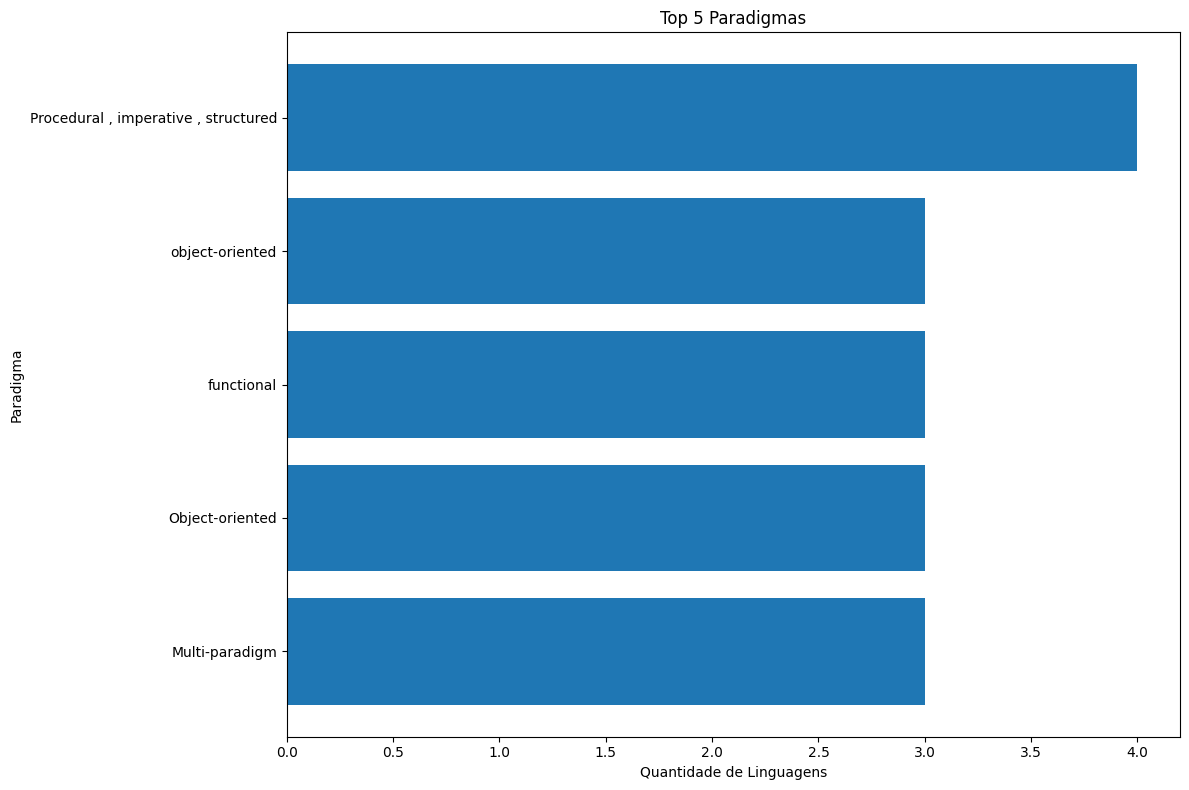

In [208]:
# Total de páginas visitadas e total de erros registrados
with ENGINE.connect() as conn:
    contagem_erros = pd.read_sql(
        """
        SELECT 
        COUNT(id)
        AS total_erros
        FROM erros_scraping
        
        """,
        conn,
    )
    contagem_pgs = pd.read_sql(
        """
        SELECT 
        COUNT(id)
        AS total_paginas
        FROM paginas_visitadas
        
        """,
        conn,
    )

    # Distribuição de erros por tipo de exceção (tabela ou gráfico).

    df_analise_erros = pd.read_sql(
        """
        SELECT
            E.tipo_erro as Excecao,
            COUNT(E.id) AS Quantidade
        FROM erros_scraping E
        GROUP BY E.tipo_erro
        ORDER BY Quantidade DESC
        """,
        conn,
    )

    # Métrica agregada adicional

    df_metrica = pd.read_sql(
        """
        SELECT
            paradigma AS Paradigma,
            COUNT(*) AS Quantidade
        FROM linguagens
        GROUP BY paradigma
        ORDER BY COUNT(*) DESC;
        """,
        conn,
    )
    #Participacao de cada Paradigma na amostra
    df_metrica["Percentual"] = (
        df_metrica["Quantidade"] / df_metrica["Quantidade"].sum() * 100
    ).round(2)

sep = "=" * 70
print(sep)

# 1
print("  RELATÓRIO FINAL")
print(sep)
print(f"Total de páginas visitadas: {contagem_pgs.iloc[0]['total_paginas']}")
print(f"Total de linguagens salvas: {len(df_linguagens)}")
print(f"Total de erros: {contagem_erros.iloc[0]['total_erros']}")
display(df_erros)
print(sep)

# 2
print(f"DISTRIBUIÇÃO DE ERROS POR TIPO DE EXCEÇÃO")
if df_analise_erros.empty:
    print("* Nenhum erro foi registrado durante o scraping")
else:
    display(df_analise_erros)
print(sep)

# 3
print(f"QUANTIDADE DE LINGUAGENS POR PARADIGMA")
display(df_metrica)
print(sep)

# 4 - Gráfico
print(f"Gráfico Top 10 Paradigmas")
df_top10 = df_metrica.head(10)



df_top10 = (
    df_metrica
    .dropna(subset=["Paradigma"])#Excluidas as que nao apresentam a informacao
    .head(5)
    )
   

plt.figure(figsize=(12, 8))
plt.barh(df_top10["Paradigma"], df_top10["Quantidade"])

plt.title("Top 5 Paradigmas")
plt.xlabel("Quantidade de Linguagens")
plt.ylabel("Paradigma")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()
